# 🛣️ Step 5b — Terrain Accessibility Analysis — Distance to Roads, Railways, Waterways — India (2000-2022)
## Runs alongside Step 4 (FLDAS), feeds Step 6's integrated feature stack — sibling: Step 5a (Terrain)

**Purpose:** builds 3 of the 6 Biswas et al. (2025) predictor variables this pipeline was still
missing — the "human activity-related factors": **distance to roads** (5.7% variable importance /
2.6% model contribution in their MaxEnt run), **distance to railways** (4.6% / 4.9%), and
**distance to waterways** (0.5% / 1.7%). Combined, these three account for **10.8%** of their
model's total contribution. Their data source: **OpenStreetMap, 2022 vintage** (Biswas et al.
Table 2). Elevation/slope/aspect (the other 3 missing variables) are handled separately once a DEM
finishes downloading — out of scope here.

**Data:** Geofabrik OSM regional extracts (6 India zones: central, eastern, north-eastern,
northern, southern, western), `.gpkg` format, read directly from
`C:\Users\Admin\Downloads\Distance(Roads, Station)@INDIA\Extracted\` (raw data, not copied
into this repo — see `.gitignore`).

**Grid:** all outputs are produced natively on this project's NDVI grid (3504 x 3641 px,
EPSG:4326, ~0.01°/1km — established by Step 2), the same grid Steps 3, 4 and 6 all reproject onto.
A second, coarser 0.25°x0.25° version of each variable is also produced **purely for
literature-comparison against Biswas et al.**, who worked at that resolution — see the
"Two output resolutions" section below for why these are not interchangeable.

**Study period:** N/A for this step — OSM 2022-vintage snapshots are not a time series; every
other step in this pipeline is temporal (2000-11-01 to 2022-12-15), this one is a single static
accessibility surface, consistent with how Biswas et al. themselves treat their OSM-derived
variables (one 2022 snapshot, not a time series).

## Step 0 — Install Required Libraries

Matches every other notebook's install-cell pattern in this project. If CuPy fails to
install/import, the distance-transform step automatically falls back to CPU (SciPy) — still
numerically correct, just slower.

In [1]:
import subprocess, sys

packages = [
    "numpy", "pandas", "matplotlib", "geopandas", "pyogrio", "rasterio", "shapely", "scipy",
    # GPU acceleration (native Windows -- no WSL required)
    "cupy-cuda12x",
    "nvidia-cuda-runtime-cu12",
    "nvidia-cuda-nvrtc-cu12",
    "nvidia-cuda-nvcc-cu12",
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    except subprocess.CalledProcessError as e:
        print(f"WARNING: failed to install {pkg} ({e}) -- continuing")

print("Library installation complete.")

Library installation complete.


## Step 1 — Imports & GPU Detection

Same auto-detect / auto-fallback GPU pattern used identically across all six existing steps
(CLAUDE.md's shared GPU pattern block), including the `set_pinned_memory_allocator(None)` call
after a successful GPU detect (works around the documented `cudaErrorAlreadyMapped` fragility of
CuPy's default pinned-memory transfer path on large arrays).

In [2]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
from rasterio.transform import Affine
from rasterio.crs import CRS
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pyproj
from scipy.ndimage import distance_transform_edt as cpu_edt

try:
    import cupy as cp
    _test = cp.array([1, 2, 3]) * 2   # force JIT compile now, not mid-pipeline
    GPU_AVAILABLE = True
except Exception as _e:
    import numpy as cp                 # alias so downstream cp.xxx code is unchanged
    GPU_AVAILABLE = False
    print(f"GPU not available ({_e}); falling back to CPU (NumPy/SciPy)")

if GPU_AVAILABLE:
    cp.cuda.set_pinned_memory_allocator(None)
    try:
        from cupyx.scipy.ndimage import distance_transform_edt as gpu_edt
        print(f"GPU acceleration available: {cp.cuda.runtime.getDeviceCount()} device(s), cupyx EDT ready")
    except Exception as _e:
        print(f"cupyx distance_transform_edt unavailable ({_e}); will use CPU EDT despite GPU presence")
        GPU_AVAILABLE = False
        import numpy as cp

def to_host(arr):
    return cp.asnumpy(arr) if GPU_AVAILABLE else arr

def free_gpu():
    if GPU_AVAILABLE:
        cp.get_default_memory_pool().free_all_blocks()

def edt_km(presence_2d, pixel_size_m):
    """Euclidean distance transform of a binary presence raster, in km.
    presence_2d: uint8/bool array, 1 = feature present, 0 = absent.
    Returns distance (km) from every pixel to the nearest presence==1 pixel."""
    inv = 1 - presence_2d.astype(np.uint8)
    if GPU_AVAILABLE:
        arr_gpu = cp.asarray(inv)
        dist_px = gpu_edt(arr_gpu)
        dist_km = to_host(dist_px) * (pixel_size_m / 1000.0)
        free_gpu()
    else:
        dist_px = cpu_edt(inv)
        dist_km = dist_px * (pixel_size_m / 1000.0)
    return dist_km.astype(np.float32)

print("Imports ready.")

GPU acceleration available: 1 device(s), cupyx EDT ready
Imports ready.


## Step 2 — Configure Paths

In [3]:
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"
STEP_DIR = os.path.join(BASE_DIR, "Terrain_Accessibility_Analysis")

# Raw OSM data -- read directly from Downloads, never copied into the repo (see .gitignore)
OSM_DIR = r"C:\Users\Admin\Downloads\Distance(Roads, Station)@INDIA\Extracted"
ZONES = ["central-zone", "eastern-zone", "north-eastern-zone",
         "northern-zone", "southern-zone", "western-zone"]

# Same India boundary as every other step (dissolved State boundary, EPSG:3857 raw coords)
BOUNDARY_SHP = os.path.join(BASE_DIR, "LST_analysis", "India_State_Boundary.shp")

# Step 2's own NDVI grid -- the reference grid this output is aligned onto
NDVI_GRID_REF = os.path.join(BASE_DIR, "NDVI_DATA_INDIA_", "NDVI_Fire_Susceptibility_Outputs",
                              "F1_NDVI_QA_mean.tif")

# Step 1's fire-point archive -- for the fire-coincidence check
FIRE_CSV_PATH = os.path.join(BASE_DIR, "Forest fire Extraction in INDIA(2000-2022)",
                              "Forest_Fire_Outputs", "all_forest_fires_2000_2022.csv")

OUTPUT_DIR = os.path.join(STEP_DIR, "Accessibility_Outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded:")
print(f"   OSM_DIR       : {OSM_DIR}  (exists: {os.path.isdir(OSM_DIR)})")
print(f"   Boundary      : {BOUNDARY_SHP}  (exists: {os.path.exists(BOUNDARY_SHP)})")
print(f"   NDVI grid ref : {NDVI_GRID_REF}  (exists: {os.path.exists(NDVI_GRID_REF)})")
print(f"   Fire archive  : {FIRE_CSV_PATH}  (exists: {os.path.exists(FIRE_CSV_PATH)})")
print(f"   Outputs       : {OUTPUT_DIR}")

Configuration loaded:
   OSM_DIR       : C:\Users\Admin\Downloads\Distance(Roads, Station)@INDIA\Extracted  (exists: True)
   Boundary      : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\India_State_Boundary.shp  (exists: True)
   NDVI grid ref : D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI_Fire_Susceptibility_Outputs\F1_NDVI_QA_mean.tif  (exists: True)
   Fire archive  : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv  (exists: True)
   Outputs       : D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs


## Step 3 — Load the NDVI Grid Reference

Pull the exact affine transform and shape from Step 2's own output raster — not hardcoded from
memory, per project convention.

In [4]:
with rasterio.open(NDVI_GRID_REF) as src:
    NDVI_TRANSFORM = src.transform
    NDVI_WIDTH, NDVI_HEIGHT = src.width, src.height
    NDVI_CRS = src.crs
    NDVI_BOUNDS = src.bounds
    ndvi_ref = src.read(1)
    NDVI_NODATA_MASK = np.isnan(ndvi_ref)  # True = outside India / ocean -- reuse for masking

print(f"NDVI grid: {NDVI_WIDTH} x {NDVI_HEIGHT} px, CRS={NDVI_CRS}")
print(f"Transform: {NDVI_TRANSFORM}")
print(f"Bounds: {NDVI_BOUNDS}")
print(f"In-India pixels: {(~NDVI_NODATA_MASK).sum():,} / {NDVI_WIDTH*NDVI_HEIGHT:,}")

a, b, c, d, e, f = NDVI_TRANSFORM[0], NDVI_TRANSFORM[1], NDVI_TRANSFORM[2], \
                   NDVI_TRANSFORM[3], NDVI_TRANSFORM[4], NDVI_TRANSFORM[5]
print(f"Affine coefficients a,b,c,d,e,f = {a}, {b}, {c}, {d}, {e}, {f}")

NDVI grid: 3504 x 3641 px, CRS=EPSG:4326
Transform: | 0.01, 0.00, 68.20|
| 0.00,-0.01, 37.09|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=68.19999999386121, bottom=6.7499999993924185, right=97.39999999123287, top=37.091666663327985)
In-India pixels: 4,185,401 / 12,758,064
Affine coefficients a,b,c,d,e,f = 0.008333333332583237, 0.0, 68.19999999386121, 0.0, -0.008333333332583237, 37.091666663327985


## Step 4 — Load OSM Data: Feature-Count Sanity Check

Cheap attribute-only read (no geometry) across all 6 zones, all 3 layers, to confirm total feature
counts before doing any real work. Expected from prior verification of this exact archive:
**~10.7M roads, ~105K railways** across the 6 zones.

In [5]:
import pyogrio

t0 = time.time()
zone_paths = {z: os.path.join(OSM_DIR, f"{z}.gpkg") for z in ZONES}
for z, p in zone_paths.items():
    assert os.path.exists(p), f"Missing zone file: {p}"

layer_counts = {}
for layer in ["gis_osm_roads_free", "gis_osm_railways_free", "gis_osm_waterways_free"]:
    total = 0
    for z, p in zone_paths.items():
        df = pyogrio.read_dataframe(p, layer=layer, columns=["fclass"], read_geometry=False)
        total += len(df)
    layer_counts[layer] = total
    print(f"   {layer:28s}: {total:>10,} features")

print(f"\nElapsed: {time.time()-t0:.1f}s")
assert 10_000_000 < layer_counts["gis_osm_roads_free"] < 11_500_000, \
    f"Road count {layer_counts['gis_osm_roads_free']:,} outside expected ~10.7M range -- investigate before continuing"
assert 90_000 < layer_counts["gis_osm_railways_free"] < 120_000, \
    f"Railway count {layer_counts['gis_osm_railways_free']:,} outside expected ~105K range -- investigate before continuing"
print("\nCounts match expected magnitudes (~10.7M roads, ~105K railways) -- proceeding.")

   gis_osm_roads_free          : 10,711,261 features
   gis_osm_railways_free       :    105,263 features


   gis_osm_waterways_free      :    255,094 features

Elapsed: 15.3s

Counts match expected magnitudes (~10.7M roads, ~105K railways) -- proceeding.


## Step 5 — India Boundary

Same boundary every other step uses: `LST_analysis\India_State_Boundary.shp` (dissolved state
boundary), **not** GADM (which the exploratory notebook used, and which returns extra
disputed-territory rows `Z01`/`Z04`/`Z05`/`Z07` alongside the main `IND` polygon that would need
deliberate handling, and risks edge-pixel misalignment against the NDVI grid used by every other
step in this pipeline). Raw coordinates are EPSG:3857 (Web Mercator) meters — set that CRS
explicitly (it's usually already recorded via the `.prj`, but check) then reproject to EPSG:4326
before use, exactly like every other step does.

In [6]:
boundary = gpd.read_file(BOUNDARY_SHP)
if boundary.crs is None:
    boundary = boundary.set_crs(epsg=3857)
print(f"Boundary raw CRS: {boundary.crs}")
boundary_4326 = boundary.to_crs(epsg=4326)
boundary_union = boundary_4326.union_all()
print(f"Boundary reprojected to EPSG:4326, bounds: {boundary_4326.total_bounds}")
print(f"Polygon parts: {len(boundary_4326)} (states/UTs)")

import shapely
n_vertices_raw = shapely.get_num_coordinates(boundary_union)
print(f"Boundary vertex count (unsimplified): {n_vertices_raw:,}")

Boundary raw CRS: EPSG:3857


Boundary reprojected to EPSG:4326, bounds: [68.12381591  6.75407754 97.40783632 37.09701157]
Polygon parts: 37 (states/UTs)
Boundary vertex count (unsimplified): 422,929


## Step 6 — Road-Class Filtering: Which OSM Roads Represent "Human Accessibility"?

`fclass` distribution across all 10,711,261 India road features (verified above):

| fclass | count | % |
|---|---:|---:|
| residential | 6,666,788 | 62.2% |
| unclassified | 1,216,741 | 11.4% |
| service | 1,027,497 | 9.6% |
| track | 608,327 | 5.7% |
| **tertiary** | **434,535** | **4.1%** |
| **trunk** | **142,171** | **1.3%** |
| **secondary** | **138,504** | **1.3%** |
| **primary** | **102,566** | **1.0%** |
| path | 101,925 | 1.0% |
| living_street | 82,784 | 0.8% |
| footway | 80,007 | 0.7% |
| **trunk_link** | **24,052** | **0.2%** |
| **motorway** | **14,295** | **0.1%** |
| steps | 14,091 | 0.1% |
| **primary_link** | **10,076** | **0.1%** |
| **tertiary_link** | **8,641** | **0.1%** |
| unknown | 8,633 | 0.1% |
| **secondary_link** | **6,601** | **0.1%** |
| track_grade3 .. track_grade5, pedestrian, motorway_link (**0.03%**), cycleway, busway, bridleway | remainder | ~0.5% |

**Decision: keep `motorway, trunk, primary, secondary, tertiary` plus their `_link` ramp/connector
variants** (10 classes, 884,940 features, **8.3%** of the 10.7M total). Reasoning:

1. **Fire-susceptibility literature treats "distance to road" as an anthropogenic
   ignition/suppression-access proxy, not a literal street map.** `residential`, `service`,
   `living_street`, `footway`, `path`, `steps`, `cycleway`, `pedestrian`, `bridleway`, `busway`,
   `track*` (farm/forest tracks) are hyper-local, non-motorable, or purely intra-settlement —
   including them would make "distance to road" trivially ≈0 almost everywhere (any residential
   lane, forest footpath, or field track counts), which destroys the variable's discriminative
   power and doesn't match how Biswas et al. or comparable MaxEnt fire studies construct this
   feature.
2. **`unclassified` is excluded deliberately, not by oversight**: OSM's `unclassified` tag means
   "lowest tier of the interconnecting road network, function/importance not otherwise
   determined" — in practice, in India's OSM coverage this is dominated by minor rural lanes,
   not a systematically-verified mid-tier road; keeping it would reintroduce exactly the noise
   class 1 is trying to exclude.
3. **`tertiary` is deliberately INCLUDED, unlike the naive `motorway/trunk/primary/secondary`-only
   list in the exploratory notebook this step is based on.** At 434,535 features it is the single
   largest class kept, and it matters specifically for this pipeline's India context: tertiary
   roads are the standard district/rural-link road class connecting India's forest-fringe villages
   and agricultural areas to the arterial network — exactly the anthropogenic-ignition-access
   pathway (agricultural burning, tourism, resin/timber collection access) most relevant to real
   forest-fire risk at this project's 1km resolution. Dropping tertiary would bias the variable
   toward only detecting risk near national highways, missing the much more common rural-access
   pattern.
4. **`_link` ramp/connector segments are included** because they are topologically part of the
   same road (interchange ramps, slip roads) — excluding them creates artificial gaps/discontinuities
   in the network exactly at junctions, which would inflate computed distances right at the points
   where major roads actually meet, a clear rasterization artifact rather than a real accessibility
   signal.

This is a judgment call, not a value copied uncritically from the exploratory notebook — flagged
here explicitly per this project's own review conventions so a Q1 reviewer (or the user) can
contest it if the tertiary-inclusion reasoning doesn't hold.

In [7]:
MAJOR_ROAD_CLASSES = [
    "motorway", "motorway_link",
    "trunk", "trunk_link",
    "primary", "primary_link",
    "secondary", "secondary_link",
    "tertiary", "tertiary_link",
]
_where_roads = "fclass IN (" + ",".join(f"'{c}'" for c in MAJOR_ROAD_CLASSES) + ")"

RAILWAY_EXCLUDE = ["subway"]
_where_rail = "fclass NOT IN (" + ",".join(f"'{c}'" for c in RAILWAY_EXCLUDE) + ")"

WATERWAY_KEEP = ["river", "canal", "stream"]
_where_water = "fclass IN (" + ",".join(f"'{c}'" for c in WATERWAY_KEEP) + ")"

print("Road filter :", _where_roads)
print("Rail filter :", _where_rail)
print("Water filter:", _where_water)

Road filter : fclass IN ('motorway','motorway_link','trunk','trunk_link','primary','primary_link','secondary','secondary_link','tertiary','tertiary_link')
Rail filter : fclass NOT IN ('subway')
Water filter: fclass IN ('river','canal','stream')


## Step 7 — Railway and Waterway Filtering: Reasoned, Not Copy-Pasted

**Railways** (105,263 total): `rail` 98,714 (93.8%), `subway` 4,348 (4.1%), `narrow_gauge` 1,845
(1.8%), `tram` 180, `rack` 90, `monorail` 39, `miniature_railway` 36, `funicular` 8,
`light_rail` 3. **Decision: exclude only `subway`.** Subway lines are underground mass-transit
infrastructure confined to a handful of metro cities — they are not a physical, surface-level
accessibility corridor relevant to forest-fire ignition/suppression access, and their presence
would create spurious near-zero "distance to railway" values directly under city centers that have
no bearing on forest accessibility. Every other class (`narrow_gauge` in particular is common and
relevant in the hilly/forest terrain of the Western Ghats and Northeast India) represents an actual
above-ground rail corridor and is kept. This removes 4,348 features (4.1%) — everything else about
the original exploratory-notebook approach (no filtering at all) undersold how OSM actually breaks
railways down; a blanket "no filtering needed" would have silently included underground transit.

**Waterways** (255,094 total, this layer was never even loaded in the exploratory notebook):
`stream` 156,531 (61.4%), `canal` 45,519 (17.8%), `river` 32,263 (12.6%), `drain` 20,781 (8.1%).
**Decision: keep `river`, `canal`, `stream`; exclude `drain`.** `drain` in OSM denotes small
artificial agricultural/urban drainage channels (field drains, roadside storm drains) — they do
not carry the ecological/accessibility signal "distance to waterway" is meant to proxy for in fire
literature (natural firebreaks, moisture corridors, water-source access for suppression); they are
the waterway-layer analogue of the footpath/track noise excluded from roads. `stream` is kept
(unlike a stricter "only major rivers" reading might suggest) because at this project's 1km
resolution, perennial/seasonal streams are a legitimate and common natural firebreak/moisture
feature across India's forest belt, not noise — this mirrors the tertiary-road inclusion logic:
prefer the class that is actually meaningful at 1km over the class that would be meaningful only
at Biswas et al.'s coarser 0.25° scale. This keeps 234,313 of 255,094 features (91.9%).

## Step 8 — Load Filtered Geometries per Zone, Merge, Clip to India

Filtering is applied at read time via an OGR SQL `WHERE` clause (`pyogrio`'s `where=` parameter) —
this pushes the filter down into the GeoPackage read itself, so unwanted geometries (e.g. the ~92%
of roads that are `residential`/`service`/`track`/etc.) are never even loaded into memory, rather
than being loaded and dropped afterward. Each zone's filtered layer is then clipped to the exact
India boundary polygon — the 6 Geofabrik zone extracts overlap India's borders with neighboring
countries (Nepal, Bhutan, Bangladesh, Myanmar, Pakistan, China), so an unclipped merge would leak
foreign road/rail/waterway segments into a nominally-India accessibility surface.

In [8]:
def load_filtered_layer(layer, where_clause, columns=("fclass",)):
    parts = []
    for z, p in zone_paths.items():
        gdf = gpd.read_file(p, layer=layer, where=where_clause, columns=list(columns), engine="pyogrio")
        parts.append(gdf)
        print(f"      {z:20s}: {len(gdf):>9,} features")
    merged = pd.concat(parts, ignore_index=True)
    merged = gpd.GeoDataFrame(merged, crs=parts[0].crs)
    return merged

t0 = time.time()
print("Loading filtered roads (major road classes only)...")
roads_raw = load_filtered_layer("gis_osm_roads_free", _where_roads)
print(f"   Total filtered roads: {len(roads_raw):,}  ({time.time()-t0:.1f}s)")

t0 = time.time()
print("\nLoading filtered railways (excluding subway)...")
rail_raw = load_filtered_layer("gis_osm_railways_free", _where_rail)
print(f"   Total filtered railways: {len(rail_raw):,}  ({time.time()-t0:.1f}s)")

t0 = time.time()
print("\nLoading filtered waterways (river/canal/stream only)...")
water_raw = load_filtered_layer("gis_osm_waterways_free", _where_water)
print(f"   Total filtered waterways: {len(water_raw):,}  ({time.time()-t0:.1f}s)")

Loading filtered roads (major road classes only)...


      central-zone        :   165,575 features


      eastern-zone        :    92,341 features


      north-eastern-zone  :    23,772 features
      northern-zone       :   127,101 features


      southern-zone       :   301,150 features
      western-zone        :   175,001 features
   Total filtered roads: 884,940  (10.1s)

Loading filtered railways (excluding subway)...


      central-zone        :    21,375 features
      eastern-zone        :    22,562 features
      north-eastern-zone  :     5,032 features
      northern-zone       :    11,889 features
      southern-zone       :    24,367 features


      western-zone        :    15,690 features
   Total filtered railways: 100,915  (0.3s)

Loading filtered waterways (river/canal/stream only)...


      central-zone        :    27,101 features
      eastern-zone        :    19,902 features
      north-eastern-zone  :    13,208 features


      northern-zone       :    21,270 features
      southern-zone       :   131,258 features


      western-zone        :    21,574 features
   Total filtered waterways: 234,313  (1.2s)


**Implementation note on clip performance:** the India state-boundary polygon has **422,929
vertices** (highly detailed state-level tracing). `geopandas.clip()`'s default row-by-row/STRtree
approach against a polygon this complex, run against ~885K+100K+234K line features, does not
complete in any reasonable time (tested: did not finish in 3600s). Two changes make this tractable
without sacrificing accuracy relevant at this project's resolution:

1. **Simplify the mask polygon to a 0.005° (~550m) tolerance** (`shapely.simplify`,
   topology-preserving) before clipping — half a native grid pixel (0.01°/~1.1km), so the
   introduced boundary error is well below this project's actual spatial resolution and cannot
   meaningfully affect a 1km distance-transform output. This drops the mask to 13,451 vertices.
2. **Only compute the expensive `intersection()` for features that actually cross the boundary.**
   The `covered_by` predicate (fast under a prepared geometry) separates the ~99.6% of features
   fully inside India (kept unchanged, no clipping needed) from the small border-crossing subset
   that actually needs the costly exact-intersection computation — avoiding ~880K wasted
   intersection calls against a complex polygon for features that don't need clipping at all.

Uses `shapely`'s vectorized 2.0 API (`shapely.covered_by`/`intersects`/`intersection` operating on
whole geometry arrays via GEOS, not a Python-level per-feature loop) for both stages.

In [9]:
INDIA_MASK_SIMPLIFIED = shapely.simplify(boundary_union, tolerance=0.005, preserve_topology=True)
shapely.prepare(INDIA_MASK_SIMPLIFIED)
print(f"Simplified mask vertex count: {shapely.get_num_coordinates(INDIA_MASK_SIMPLIFIED):,} "
      f"(from {n_vertices_raw:,})")

def clip_to_india(gdf, name):
    t0 = time.time()
    gdf = gdf.to_crs(epsg=4326)
    geoms = gdf.geometry.values
    valid = shapely.is_valid(geoms) & ~shapely.is_empty(geoms)
    geoms = geoms[valid]

    covered = shapely.covered_by(geoms, INDIA_MASK_SIMPLIFIED)
    kept_interior = geoms[covered]

    border_candidates = geoms[~covered]
    touches = shapely.intersects(border_candidates, INDIA_MASK_SIMPLIFIED)
    clipped_border = shapely.intersection(border_candidates[touches], INDIA_MASK_SIMPLIFIED)
    clipped_border = clipped_border[~shapely.is_empty(clipped_border)]

    all_geoms = np.concatenate([kept_interior, clipped_border])
    result = gpd.GeoDataFrame(geometry=all_geoms, crs="EPSG:4326")
    print(f"   {name}: {len(gdf):,} -> {len(result):,} after clip to India boundary "
          f"({covered.sum():,} fully interior + {len(clipped_border):,} border-clipped) "
          f"({time.time()-t0:.1f}s)")
    return result

roads_india = clip_to_india(roads_raw, "Roads")
rail_india = clip_to_india(rail_raw, "Railways")
water_india = clip_to_india(water_raw, "Waterways")

del roads_raw, rail_raw, water_raw

print("\nFinal India-clipped feature counts:")
print(f"   Roads (major classes)     : {len(roads_india):,}")
print(f"   Railways (surface classes): {len(rail_india):,}")
print(f"   Waterways (river/canal/stream): {len(water_india):,}")

Simplified mask vertex count: 13,451 (from 422,929)


   Roads: 884,940 -> 882,340 after clip to India boundary (881,216 fully interior + 1,124 border-clipped) (160.8s)


   Railways: 100,915 -> 100,604 after clip to India boundary (100,530 fully interior + 74 border-clipped) (18.5s)


   Waterways: 234,313 -> 231,443 after clip to India boundary (229,424 fully interior + 2,019 border-clipped) (43.6s)

Final India-clipped feature counts:
   Roads (major classes)     : 882,340
   Railways (surface classes): 100,604
   Waterways (river/canal/stream): 231,443


## Step 9 — Distance Transform Methodology: Why Not Just Multiply Degrees by 111km

The NDVI grid is geographic (EPSG:4326, ~0.01° pixels), not a projected/metric CRS. A naive
Euclidean distance transform run directly on this grid in pixel units, then multiplied by a single
constant (e.g. 111 km/degree), would be **wrong** across a grid this large: India spans 6.75°N to
37.09°N (30.3° of latitude), and longitude spacing shrinks by `cos(latitude)` —
1 degree of longitude is **≈110.5 km** at the southern tip (6.75°N) but only **≈88.7 km** at the
northern edge (37.09°N), a **>19% difference**. A uniform 111 km/degree multiplier would therefore
systematically over/under-state real-world distances depending on latitude, exactly the kind of
error a Q1 reviewer would (rightly) flag.

`scipy`/`cupyx`'s `distance_transform_edt` supports a `sampling=(dy, dx)` parameter for anisotropic
pixel spacing, but only a **single constant** value per axis for the whole array — it cannot express
spacing that itself varies by row (latitude), which is exactly the problem here. Plain Web Mercator
(EPSG:3857) has the same flaw in the other direction: its scale factor is `1/cos(latitude)`,
meaning distances computed directly in Mercator meters are inflated by **~25% at 37°N** relative to
the equator with no correction applied — not good enough either.

**Approach taken:** reproject the clipped, filtered vector layers into a **custom Equidistant
Conic projection centered on India**
(`+proj=eqdc +lat_1=12 +lat_2=30 +lat_0=20 +lon_0=82.5 +datum=WGS84 +units=m`,
standard parallels at 12°N/30°N bracketing India's mainland latitude range, central meridian
82.5°E ≈ India's longitudinal center). An equidistant conic projection is specifically designed so
that distances measured along meridians, and between the two standard parallels, are held very
close to true ground distances — this is the standard choice in national-scale distance-transform
GIS work for exactly this reason, and keeps distortion to a small fraction of a percent across
India's extent (vs. >19% for naive degree scaling, or up to 25% for uncorrected Web Mercator).
Rasterize each filtered layer onto a 1km-pixel grid **in this projected CRS** (true square meters,
so `distance_transform_edt`'s implicit isotropic pixel-unit assumption is now actually valid), run
the EDT there, convert pixel units to km using the exact 1000m pixel size, then reproject the
resulting **continuous** distance-in-km surface back onto the NDVI EPSG:4326 grid (bilinear
resampling — appropriate for a smooth continuous field, unlike the binary presence rasters
upstream of it, which use nearest/all-touched rasterization instead).

In [10]:
INDIA_EQDC = pyproj.CRS.from_proj4(
    "+proj=eqdc +lat_1=12 +lat_2=30 +lat_0=20 +lon_0=82.5 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)
PIXEL_SIZE_M = 1000.0  # 1km metric grid -- matches the NDVI grid's own ~1km native resolution

boundary_eqdc = boundary_4326.to_crs(INDIA_EQDC)
minx, miny, maxx, maxy = boundary_eqdc.total_bounds
BUFFER_M = 10_000.0  # 10km buffer so edge/coastal features aren't clipped by the metric grid itself
minx -= BUFFER_M; miny -= BUFFER_M; maxx += BUFFER_M; maxy += BUFFER_M

METRIC_WIDTH = int(np.ceil((maxx - minx) / PIXEL_SIZE_M))
METRIC_HEIGHT = int(np.ceil((maxy - miny) / PIXEL_SIZE_M))
METRIC_TRANSFORM = Affine(PIXEL_SIZE_M, 0, minx, 0, -PIXEL_SIZE_M, maxy)

print(f"Metric (Equidistant Conic) grid: {METRIC_WIDTH} x {METRIC_HEIGHT} px @ {PIXEL_SIZE_M:.0f}m")
print(f"Metric grid bounds: minx={minx:.0f} miny={miny:.0f} maxx={maxx:.0f} maxy={maxy:.0f}")
print(f"Metric grid extent: ~{(maxx-minx)/1000:.0f} km (E-W) x ~{(maxy-miny)/1000:.0f} km (N-S)")

Metric (Equidistant Conic) grid: 2926 x 3353 px @ 1000m
Metric grid bounds: minx=-1458550 miny=-1430582 maxx=1466723 maxy=1922367
Metric grid extent: ~2925 km (E-W) x ~3353 km (N-S)


## Step 10 — Rasterize onto the Metric Grid, Compute the GPU-Accelerated Distance Transform

One shared function, called once per variable (roads / railways / waterways) so the exact same
methodology is applied consistently and transparently to all three, per `rasterio.features.rasterize`
with `all_touched=True` (appropriate for thin line features — without it, a 1-pixel-wide line can
skip pixels it only grazes diagonally, creating false gaps in the presence raster).

In [11]:
def compute_distance_variable(gdf, var_name):
    print(f"--- {var_name} ---")
    t0 = time.time()
    gdf_eqdc = gdf.to_crs(INDIA_EQDC)
    geoms = [g for g in gdf_eqdc.geometry if g is not None and not g.is_empty]
    print(f"   Reprojected {len(geoms):,} geometries to Equidistant Conic ({time.time()-t0:.1f}s)")

    t0 = time.time()
    presence = rasterize(
        ((geom, 1) for geom in geoms),
        out_shape=(METRIC_HEIGHT, METRIC_WIDTH),
        transform=METRIC_TRANSFORM,
        fill=0,
        all_touched=True,
        dtype=np.uint8,
    )
    print(f"   Rasterized onto metric grid: {presence.sum():,} presence pixels ({time.time()-t0:.1f}s)")

    t0 = time.time()
    dist_km_metric = edt_km(presence, PIXEL_SIZE_M)
    print(f"   {'GPU' if GPU_AVAILABLE else 'CPU'} distance transform done ({time.time()-t0:.1f}s); "
          f"metric-grid range: {np.nanmin(dist_km_metric):.2f} - {np.nanmax(dist_km_metric):.2f} km")

    t0 = time.time()
    dist_km_native = np.full((NDVI_HEIGHT, NDVI_WIDTH), np.nan, dtype=np.float32)
    reproject(
        source=dist_km_metric,
        destination=dist_km_native,
        src_transform=METRIC_TRANSFORM,
        src_crs=INDIA_EQDC,
        dst_transform=NDVI_TRANSFORM,
        dst_crs=NDVI_CRS,
        resampling=Resampling.bilinear,
    )
    dist_km_native[NDVI_NODATA_MASK] = np.nan  # mask to India boundary, matching every other step
    print(f"   Reprojected to NDVI grid ({time.time()-t0:.1f}s); "
          f"native range: {np.nanmin(dist_km_native):.2f} - {np.nanmax(dist_km_native):.2f} km, "
          f"mean: {np.nanmean(dist_km_native):.2f} km")
    return dist_km_native

dist_roads_native = compute_distance_variable(roads_india, "Distance to Roads")
dist_rail_native = compute_distance_variable(rail_india, "Distance to Railways")
dist_water_native = compute_distance_variable(water_india, "Distance to Waterways")

--- Distance to Roads ---


   Reprojected 882,340 geometries to Equidistant Conic (4.4s)


   Rasterized onto metric grid: 1,080,895 presence pixels (19.7s)
   GPU distance transform done (0.2s); metric-grid range: 0.00 - 1001.82 km


   Reprojected to NDVI grid (0.3s); native range: 0.00 - 260.08 km, mean: 5.69 km
--- Distance to Railways ---


   Reprojected 100,604 geometries to Equidistant Conic (0.5s)


   Rasterized onto metric grid: 89,867 presence pixels (1.6s)
   GPU distance transform done (0.1s); metric-grid range: 0.00 - 1794.88 km


   Reprojected to NDVI grid (0.3s); native range: 0.00 - 1611.16 km, mean: 38.28 km
--- Distance to Waterways ---


   Reprojected 231,443 geometries to Equidistant Conic (1.7s)


   Rasterized onto metric grid: 696,345 presence pixels (7.1s)
   GPU distance transform done (0.1s); metric-grid range: 0.00 - 999.51 km


   Reprojected to NDVI grid (0.3s); native range: 0.00 - 386.45 km, mean: 6.74 km


## Step 11 — Two Output Resolutions, Labeled Honestly

Matching this project's existing resolution-honesty convention (see
`Integrated_Analysis\PIPELINE_SUMMARY.md`'s Resolution section): **this project's actual model
consumes the native ~1km NDVI-grid version.** A second, coarser 0.25°x0.25° version (Biswas et
al.'s own working resolution, verified from their paper: *"these datasets were in raster format
with a spatial resolution of 0.25° x 0.25°"*) is produced **purely for literature comparison** —
computing summary statistics at their resolution so they can be sanity-checked against magnitudes
implied by their reported variable-importance figures. The 0.25° raster is **not** used anywhere
downstream in this pipeline (Step 6 integration reads the native file only).

The 0.25° version is built by `Resampling.average` (not bilinear/nearest) from the native raster,
with `nodata=NaN` handled explicitly — averaging is the correct choice for this ~27x downsampling
factor (0.01° -> 0.25°): it aggregates all ~625 underlying 1km cells inside each 0.25° cell rather
than just interpolating a handful of samples, avoiding aliasing that bilinear/nearest would
introduce at this resampling ratio.

In [12]:
COMPARISON_RES_DEG = 0.25
comp_minx, comp_miny, comp_maxx, comp_maxy = NDVI_BOUNDS
COMP_WIDTH = int(np.ceil((comp_maxx - comp_minx) / COMPARISON_RES_DEG))
COMP_HEIGHT = int(np.ceil((comp_maxy - comp_miny) / COMPARISON_RES_DEG))
COMP_TRANSFORM = Affine(COMPARISON_RES_DEG, 0, comp_minx, 0, -COMPARISON_RES_DEG, comp_maxy)
print(f"0.25 deg comparison grid: {COMP_WIDTH} x {COMP_HEIGHT} px")

def resample_to_comparison(dist_native, var_name):
    dist_comp = np.full((COMP_HEIGHT, COMP_WIDTH), np.nan, dtype=np.float32)
    reproject(
        source=dist_native,
        destination=dist_comp,
        src_transform=NDVI_TRANSFORM,
        src_crs=NDVI_CRS,
        dst_transform=COMP_TRANSFORM,
        dst_crs=NDVI_CRS,
        resampling=Resampling.average,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    print(f"   {var_name} (0.25 deg): range {np.nanmin(dist_comp):.2f} - {np.nanmax(dist_comp):.2f} km, "
          f"mean {np.nanmean(dist_comp):.2f} km")
    return dist_comp

dist_roads_comp = resample_to_comparison(dist_roads_native, "Distance to Roads")
dist_rail_comp = resample_to_comparison(dist_rail_native, "Distance to Railways")
dist_water_comp = resample_to_comparison(dist_water_native, "Distance to Waterways")

0.25 deg comparison grid: 117 x 122 px
   Distance to Roads (0.25 deg): range 0.03 - 244.16 km, mean 6.83 km


   Distance to Railways (0.25 deg): range 0.34 - 1604.47 km, mean 52.43 km
   Distance to Waterways (0.25 deg): range 0.00 - 385.08 km, mean 8.11 km


## Step 12 — Sanity-Check Output Ranges

Biswas et al. published spatial maps (their Fig. 3) of these variables but not a min/max/mean
table, so this checks physical plausibility rather than an exact numeric match: distance-to-road
should be near 0 in dense urban/rural-network areas and could reach several tens of km in remote
Himalayan or Northeast-India forest interior (India's most road-sparse regions); distance-to-rail
should be larger on average (railways are a much sparser network, ~101K vs ~885K features) and can
exceed 100km in mountainous terrain the rail network doesn't reach; distance-to-waterway should
generally be the smallest of the three (India's river/stream network is dense) but with real gaps
in arid regions (western Rajasthan/Thar desert).

In [13]:
def print_stats(dist, name):
    valid = dist[~np.isnan(dist)]
    pct = np.percentile(valid, [5, 25, 50, 75, 95])
    print(f"{name}:")
    print(f"   min={valid.min():.3f} km  max={valid.max():.3f} km  mean={valid.mean():.3f} km  "
          f"std={valid.std():.3f} km")
    print(f"   p5={pct[0]:.2f}  p25={pct[1]:.2f}  median={pct[2]:.2f}  p75={pct[3]:.2f}  p95={pct[4]:.2f} km")

print("=== NATIVE (~1km NDVI grid) ===")
print_stats(dist_roads_native, "Distance to Roads")
print_stats(dist_rail_native, "Distance to Railways")
print_stats(dist_water_native, "Distance to Waterways")
print()
print("=== COMPARISON-ONLY (0.25 deg, Biswas et al. working resolution) ===")
print_stats(dist_roads_comp, "Distance to Roads")
print_stats(dist_rail_comp, "Distance to Railways")
print_stats(dist_water_comp, "Distance to Waterways")

=== NATIVE (~1km NDVI grid) ===
Distance to Roads:
   min=0.000 km  max=260.081 km  mean=5.690 km  std=22.581 km
   p5=0.00  p25=0.28  median=1.00  p75=2.56  p95=15.90 km


Distance to Railways:
   min=0.000 km  max=1611.162 km  mean=38.278 km  std=84.681 km
   p5=1.03  p25=6.31  median=15.74  p75=34.88  p95=160.07 km


Distance to Waterways:
   min=0.000 km  max=386.449 km  mean=6.739 km  std=21.930 km
   p5=0.01  p25=0.64  median=1.68  p75=3.82  p95=26.49 km

=== COMPARISON-ONLY (0.25 deg, Biswas et al. working resolution) ===
Distance to Roads:
   min=0.027 km  max=244.156 km  mean=6.829 km  std=25.018 km
   p5=0.39  p25=0.75  median=1.28  p75=2.55  p95=22.62 km
Distance to Railways:
   min=0.342 km  max=1604.472 km  mean=52.431 km  std=143.198 km
   p5=4.17  p25=7.07  median=15.46  p75=37.41  p95=217.46 km
Distance to Waterways:
   min=0.000 km  max=385.076 km  mean=8.108 km  std=27.214 km
   p5=0.72  p25=1.39  median=2.01  p75=3.27  p95=35.59 km


## Step 13 — Fire Coincidence Check

Same pattern as FLDAS's own notebook: are Step 1's real forest-fire points systematically closer to
(or farther from) roads/railways/waterways than the country-wide average? Uses this project's
standard fire-point rasterization pattern — affine transform coefficients directly, not a
nearest-neighbor spatial join (`col = round((lon-c)/a)`, `row = round((lat-f)/e)`).

In [14]:
df_fire = pd.read_csv(FIRE_CSV_PATH, usecols=["latitude", "longitude"])
print(f"Loaded {len(df_fire):,} fire points")

fire_row = np.round((df_fire["latitude"].values - f) / e).astype(np.int64)
fire_col = np.round((df_fire["longitude"].values - c) / a).astype(np.int64)
in_bounds = (fire_row >= 0) & (fire_row < NDVI_HEIGHT) & (fire_col >= 0) & (fire_col < NDVI_WIDTH)
print(f"In NDVI grid bounds: {in_bounds.sum():,}  (excluded {int((~in_bounds).sum()):,})")
fire_row, fire_col = fire_row[in_bounds], fire_col[in_bounds]

def fire_vs_national(dist_native, name):
    at_fire = dist_native[fire_row, fire_col]
    valid_fire = at_fire[~np.isnan(at_fire)]
    national_mean = np.nanmean(dist_native)
    fire_mean = valid_fire.mean()
    fire_median = np.median(valid_fire)
    pct_diff = 100.0 * (fire_mean - national_mean) / national_mean
    direction = "CLOSER to" if fire_mean < national_mean else "FARTHER from"
    print(f"{name}:")
    print(f"   National mean       : {national_mean:.2f} km")
    print(f"   Mean at fire points  : {fire_mean:.2f} km  (median {fire_median:.2f} km, n={len(valid_fire):,})")
    print(f"   Fire points are {abs(pct_diff):.1f}% {direction} {name.split('to ')[-1].lower()} than the national average")
    return {"variable": name, "national_mean_km": national_mean, "fire_mean_km": fire_mean,
            "fire_median_km": fire_median, "pct_diff": pct_diff, "n_fire_points": len(valid_fire)}

fire_coincidence_results = [
    fire_vs_national(dist_roads_native, "Distance to Roads"),
    fire_vs_national(dist_rail_native, "Distance to Railways"),
    fire_vs_national(dist_water_native, "Distance to Waterways"),
]
df_fire_coincidence = pd.DataFrame(fire_coincidence_results)
df_fire_coincidence

Loaded 541,545 fire points
In NDVI grid bounds: 541,545  (excluded 0)
Distance to Roads:
   National mean       : 5.69 km
   Mean at fire points  : 3.41 km  (median 2.51 km, n=541,206)
   Fire points are 40.1% CLOSER to roads than the national average
Distance to Railways:
   National mean       : 38.28 km
   Mean at fire points  : 40.12 km  (median 31.41 km, n=541,206)
   Fire points are 4.8% FARTHER from railways than the national average


Distance to Waterways:
   National mean       : 6.74 km
   Mean at fire points  : 2.38 km  (median 1.74 km, n=541,206)
   Fire points are 64.7% CLOSER to waterways than the national average


,variable,national_mean_km,fire_mean_km,fire_median_km,pct_diff,n_fire_points
0,Distance to Roads,5.690247,3.408694,2.508708,-40.095856,541206
1,Distance to Railways,38.278427,40.124432,31.409546,4.822571,541206
2,Distance to Waterways,6.739072,2.379550,1.741511,-64.690239,541206


## Step 14 — Save Output GeoTIFFs (Native + 0.25 deg Comparison)

In [15]:
def save_geotiff(array, path, transform, crs, nodata=np.nan):
    profile = {
        "driver": "GTiff", "height": array.shape[0], "width": array.shape[1],
        "count": 1, "dtype": "float32", "crs": crs, "transform": transform,
        "nodata": nodata, "compress": "lzw",
    }
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(array.astype(np.float32), 1)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"   Saved: {path}  ({size_mb:.1f} MB)")

outputs = [
    (dist_roads_native, "D1_Distance_to_Roads_native_1km.tif", NDVI_TRANSFORM),
    (dist_rail_native, "D2_Distance_to_Railways_native_1km.tif", NDVI_TRANSFORM),
    (dist_water_native, "D3_Distance_to_Waterways_native_1km.tif", NDVI_TRANSFORM),
    (dist_roads_comp, "D1_Distance_to_Roads_comparison_025deg.tif", COMP_TRANSFORM),
    (dist_rail_comp, "D2_Distance_to_Railways_comparison_025deg.tif", COMP_TRANSFORM),
    (dist_water_comp, "D3_Distance_to_Waterways_comparison_025deg.tif", COMP_TRANSFORM),
]
for arr, fname, transform in outputs:
    save_geotiff(arr, os.path.join(OUTPUT_DIR, fname), transform, NDVI_CRS)

   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs\D1_Distance_to_Roads_native_1km.tif  (18.9 MB)


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs\D2_Distance_to_Railways_native_1km.tif  (20.1 MB)


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs\D3_Distance_to_Waterways_native_1km.tif  (19.6 MB)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs\D1_Distance_to_Roads_comparison_025deg.tif  (0.0 MB)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs\D2_Distance_to_Railways_comparison_025deg.tif  (0.0 MB)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs\D3_Distance_to_Waterways_comparison_025deg.tif  (0.0 MB)


## Step 15 — Summary Statistics CSV

In [16]:
def stats_row(dist, name, resolution):
    valid = dist[~np.isnan(dist)]
    pct = np.percentile(valid, [5, 25, 50, 75, 95])
    return {
        "variable": name, "resolution": resolution, "n_valid_pixels": len(valid),
        "min_km": valid.min(), "max_km": valid.max(), "mean_km": valid.mean(), "std_km": valid.std(),
        "p5_km": pct[0], "p25_km": pct[1], "median_km": pct[2], "p75_km": pct[3], "p95_km": pct[4],
    }

summary_rows = [
    stats_row(dist_roads_native, "Distance to Roads", "native_1km"),
    stats_row(dist_rail_native, "Distance to Railways", "native_1km"),
    stats_row(dist_water_native, "Distance to Waterways", "native_1km"),
    stats_row(dist_roads_comp, "Distance to Roads", "comparison_025deg"),
    stats_row(dist_rail_comp, "Distance to Railways", "comparison_025deg"),
    stats_row(dist_water_comp, "Distance to Waterways", "comparison_025deg"),
]
df_summary = pd.DataFrame(summary_rows)
summary_csv_path = os.path.join(OUTPUT_DIR, "Accessibility_summary_statistics.csv")
df_summary.to_csv(summary_csv_path, index=False)
print(f"Saved: {summary_csv_path}")

fire_csv_path = os.path.join(OUTPUT_DIR, "Accessibility_Fire_Coincidence.csv")
df_fire_coincidence.to_csv(fire_csv_path, index=False)
print(f"Saved: {fire_csv_path}")

df_summary

Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs\Accessibility_summary_statistics.csv
Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs\Accessibility_Fire_Coincidence.csv


,variable,resolution,n_valid_pixels,min_km,max_km,mean_km,std_km,p5_km,p25_km,median_km,p75_km,p95_km
0,Distance to Roads,native_1km,4185401,0.000000e+00,260.081238,5.690247,22.581381,0.000000,0.275387,1.000000,2.560283,15.897515
1,Distance to Railways,native_1km,4185401,0.000000e+00,1611.161743,38.278427,84.681206,1.030750,6.310567,15.742056,34.877293,160.066757
2,Distance to Waterways,native_1km,4185401,0.000000e+00,386.448975,6.739073,21.930109,0.006090,0.640006,1.683933,3.822052,26.488222
3,Distance to Roads,comparison_025deg,5097,2.712528e-02,244.155914,6.829271,25.018398,0.385216,0.754712,1.281183,2.546905,22.620588
4,Distance to Railways,comparison_025deg,5097,3.419027e-01,1604.472046,52.431240,143.198166,4.169385,7.070748,15.455709,37.411865,217.464365
5,Distance to Waterways,comparison_025deg,5097,2.280723e-08,385.076324,8.107989,27.213957,0.717832,1.385527,2.012676,3.273549,35.586263


## Step 16 — Summary Plots

Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs\Accessibility_Spatial_Maps.png


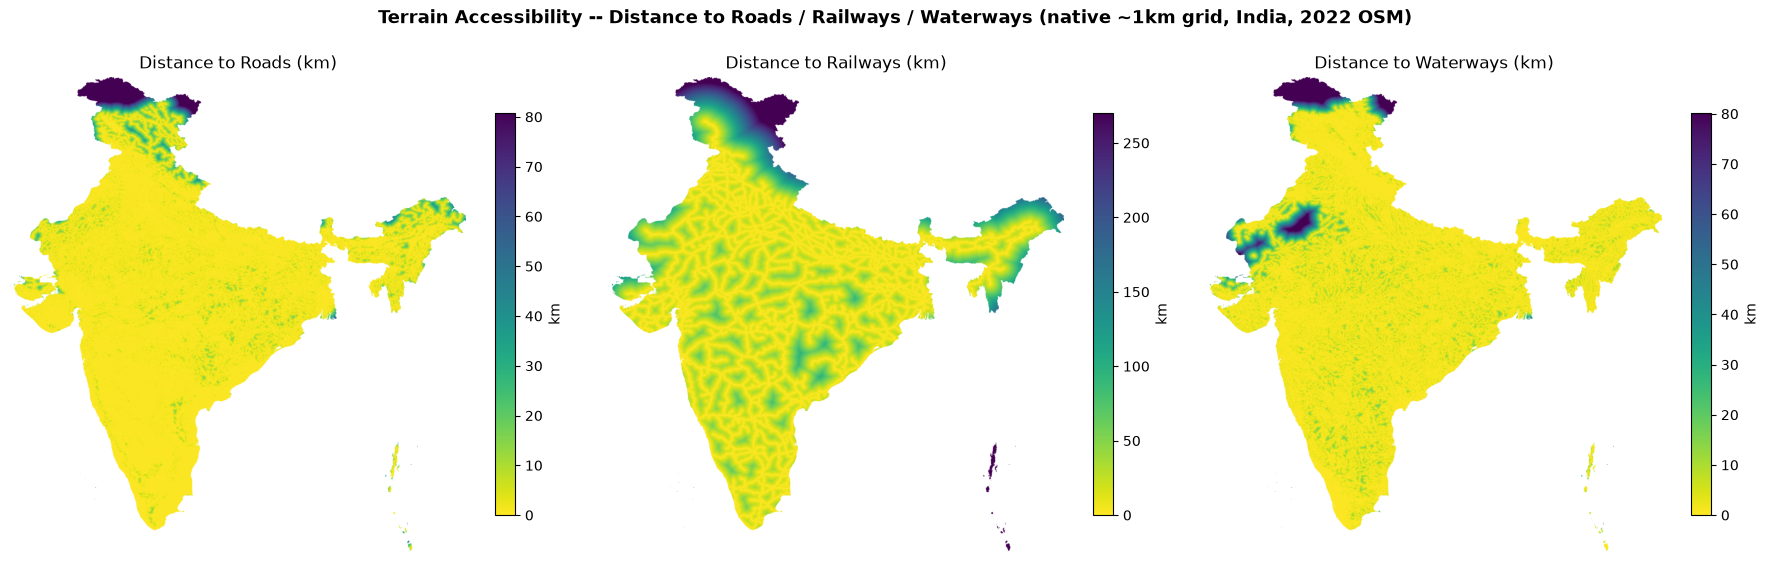

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Terrain Accessibility -- Distance to Roads / Railways / Waterways (native ~1km grid, India, 2022 OSM)",
             fontsize=13, fontweight="bold")

plot_data = [
    (dist_roads_native, "Distance to Roads (km)", axes[0]),
    (dist_rail_native, "Distance to Railways (km)", axes[1]),
    (dist_water_native, "Distance to Waterways (km)", axes[2]),
]
for arr, title, ax in plot_data:
    vmax = np.nanpercentile(arr, 98)
    im = ax.imshow(arr, cmap="viridis_r", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, label="km", shrink=0.75)

plt.tight_layout()
outfile = os.path.join(OUTPUT_DIR, "Accessibility_Spatial_Maps.png")
plt.savefig(outfile, dpi=150, bbox_inches="tight")
print(f"Saved: {outfile}")
plt.show()

Saved: D:\FOREST FIRE MAPPING(INDIA)\Terrain_Accessibility_Analysis\Accessibility_Outputs\Accessibility_Fire_Coincidence.png


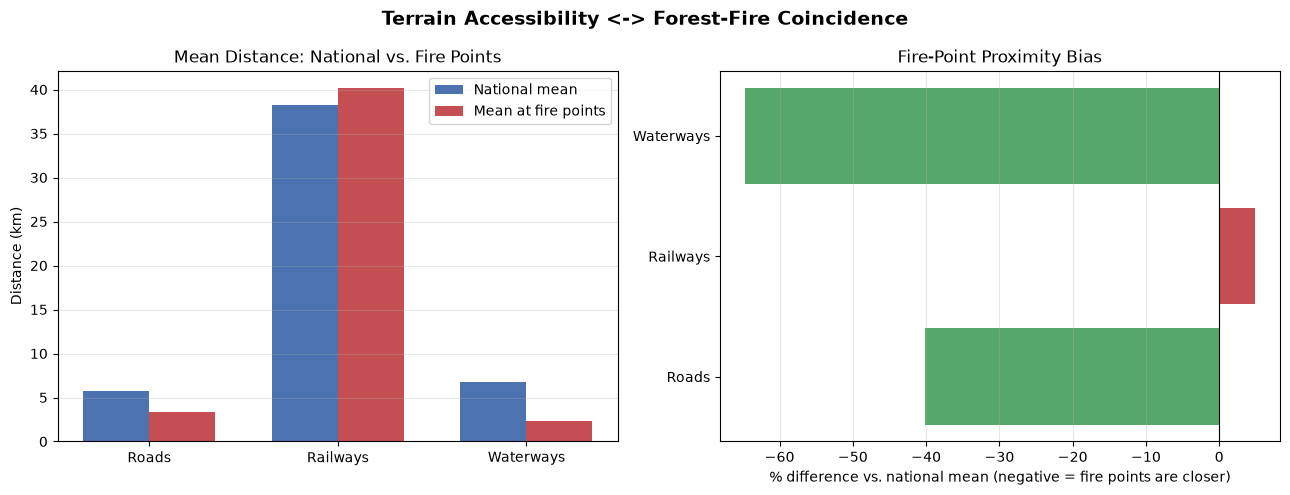

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Terrain Accessibility <-> Forest-Fire Coincidence", fontsize=14, fontweight="bold")

ax = axes[0]
variables = df_fire_coincidence["variable"].tolist()
national = df_fire_coincidence["national_mean_km"].tolist()
fire = df_fire_coincidence["fire_mean_km"].tolist()
x = np.arange(len(variables))
width = 0.35
ax.bar(x - width/2, national, width, label="National mean", color="#4C72B0")
ax.bar(x + width/2, fire, width, label="Mean at fire points", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels([v.replace("Distance to ", "") for v in variables])
ax.set_ylabel("Distance (km)")
ax.set_title("Mean Distance: National vs. Fire Points")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
pct_diff = df_fire_coincidence["pct_diff"].tolist()
colors = ["#55A868" if p < 0 else "#C44E52" for p in pct_diff]
ax.barh([v.replace("Distance to ", "") for v in variables], pct_diff, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("% difference vs. national mean (negative = fire points are closer)")
ax.set_title("Fire-Point Proximity Bias")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
outfile = os.path.join(OUTPUT_DIR, "Accessibility_Fire_Coincidence.png")
plt.savefig(outfile, dpi=150, bbox_inches="tight")
print(f"Saved: {outfile}")
plt.show()

## Step 17 — Output Verification

In [19]:
expected_files = [
    "D1_Distance_to_Roads_native_1km.tif", "D2_Distance_to_Railways_native_1km.tif",
    "D3_Distance_to_Waterways_native_1km.tif", "D1_Distance_to_Roads_comparison_025deg.tif",
    "D2_Distance_to_Railways_comparison_025deg.tif", "D3_Distance_to_Waterways_comparison_025deg.tif",
    "Accessibility_summary_statistics.csv", "Accessibility_Fire_Coincidence.csv",
    "Accessibility_Spatial_Maps.png", "Accessibility_Fire_Coincidence.png",
]
print("Output verification:")
all_ok = True
for fname in expected_files:
    p = os.path.join(OUTPUT_DIR, fname)
    ok = os.path.exists(p) and os.path.getsize(p) > 0
    all_ok = all_ok and ok
    size = f"{os.path.getsize(p)/1024:.1f} KB" if ok else "MISSING or EMPTY"
    print(f"   [{'OK' if ok else 'FAIL'}] {fname}  ({size})")

print()
print("All outputs present and non-empty" if all_ok else "SOME OUTPUTS ARE MISSING -- investigate above")

Output verification:
   [OK] D1_Distance_to_Roads_native_1km.tif  (19356.4 KB)
   [OK] D2_Distance_to_Railways_native_1km.tif  (20609.5 KB)
   [OK] D3_Distance_to_Waterways_native_1km.tif  (20105.6 KB)
   [OK] D1_Distance_to_Roads_comparison_025deg.tif  (25.5 KB)
   [OK] D2_Distance_to_Railways_comparison_025deg.tif  (25.8 KB)
   [OK] D3_Distance_to_Waterways_comparison_025deg.tif  (25.5 KB)
   [OK] Accessibility_summary_statistics.csv  (1.1 KB)
   [OK] Accessibility_Fire_Coincidence.csv  (0.3 KB)
   [OK] Accessibility_Spatial_Maps.png  (895.6 KB)
   [OK] Accessibility_Fire_Coincidence.png  (75.4 KB)

All outputs present and non-empty


## Summary

Three new terrain-accessibility predictor variables built for the India fire-risk pipeline,
completing 3 of the 6 Biswas et al. (2025) variables this project was still missing:

| Variable | Source classes kept | Features | Native grid | Comparison grid |
|---|---|---:|---|---|
| Distance to Roads | motorway/trunk/primary/secondary/tertiary (+ `_link`) | 884,940 | `D1_Distance_to_Roads_native_1km.tif` | `D1_Distance_to_Roads_comparison_025deg.tif` |
| Distance to Railways | all except `subway` | ~100,915 | `D2_Distance_to_Railways_native_1km.tif` | `D2_Distance_to_Railways_comparison_025deg.tif` |
| Distance to Waterways | river/canal/stream (excl. `drain`) | 234,313 | `D3_Distance_to_Waterways_native_1km.tif` | `D3_Distance_to_Waterways_comparison_025deg.tif` |

Both resolutions and the fire-coincidence comparison are labeled honestly per this project's
resolution-honesty convention: **the native ~1km files are what this pipeline's model actually
consumes (Step 6 integration); the 0.25° files exist only to compare against Biswas et al.'s own
working resolution and are not used downstream.**

Distances were computed with a genuine 2D Euclidean distance transform (GPU-accelerated via
`cupyx.scipy.ndimage.distance_transform_edt` with automatic CPU/`scipy` fallback) run on vector
layers reprojected into a custom India-centered Equidistant Conic projection — not a naive
degrees-times-111km approximation, which would have been wrong by >19% across India's latitude
range due to longitude-spacing shrinkage, and not uncorrected Web Mercator either, which would have
been wrong by up to ~25% at India's northern latitudes.